✅ Kaggle credentials set

✅ Dataset ready | Classes: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
  angry       : train=3,995  test= 958
  disgust     : train=  436  test= 111
  fear        : train=4,097  test=1,024
  happy       : train=7,215  test=1,774
  neutral     : train=4,965  test=1,233
  sad         : train=4,830  test=1,247
  surprise    : train=3,171  test= 831
Device: cuda
  Train : 28,709
  Val   : 3,589  (50% test folder — model selection only)
  Test  : 3,589  (50% test folder — held out, ONE evaluation at end)

CNN baseline | Parameters: 2,358,375

  Ep          LR   Tr Loss   Tr Acc   Va Loss   Va Acc
────────────────────────────────────────────────────────────
   1    8.40e-05    2.2263   13.24%    2.0805    4.40% ★
   2    1.08e-04    2.1283   17.52%    1.9700   20.79% ★
   3    1.32e-04    2.0346   24.74%    1.8784   29.51% ★
   4    1.56e-04    1.9589   30.45%    1.7990   41.40% ★
   5    1.80e-04    1.8838   35.53%    1.7524   43.58% ★
   6 

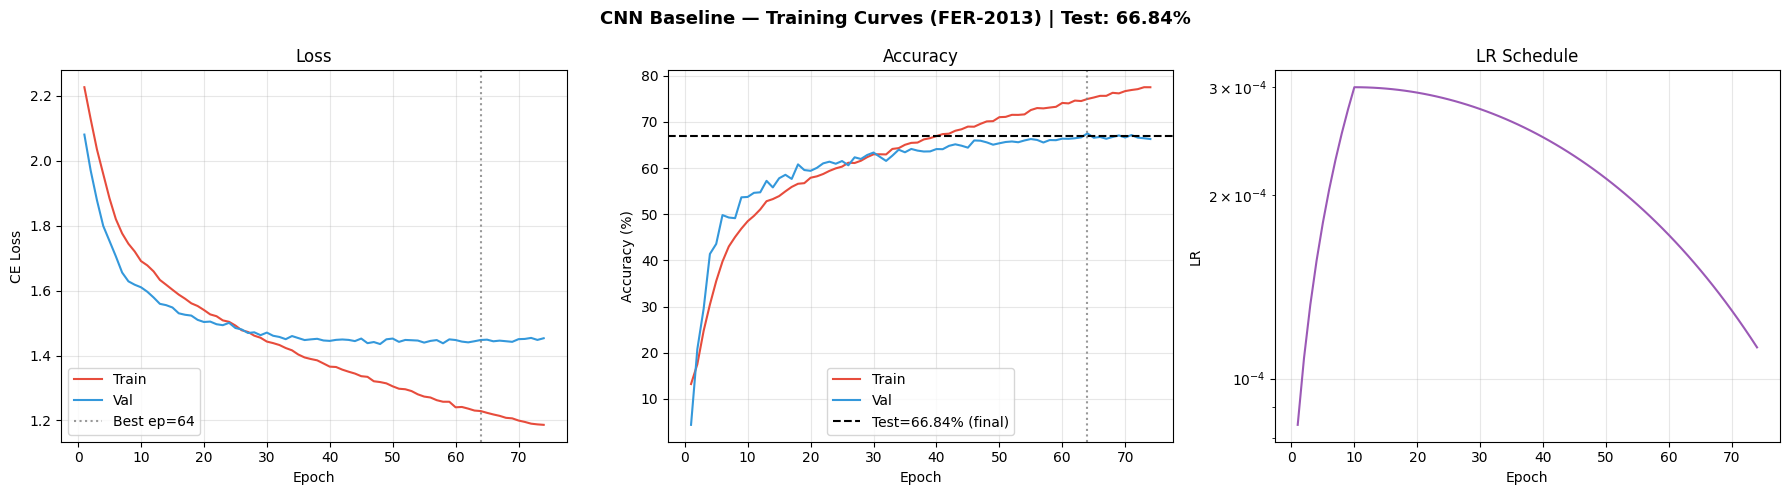

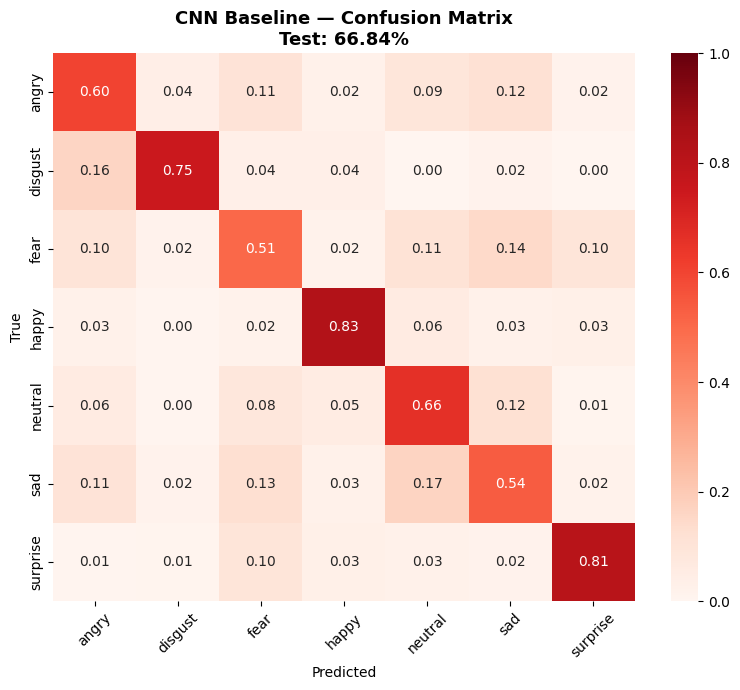

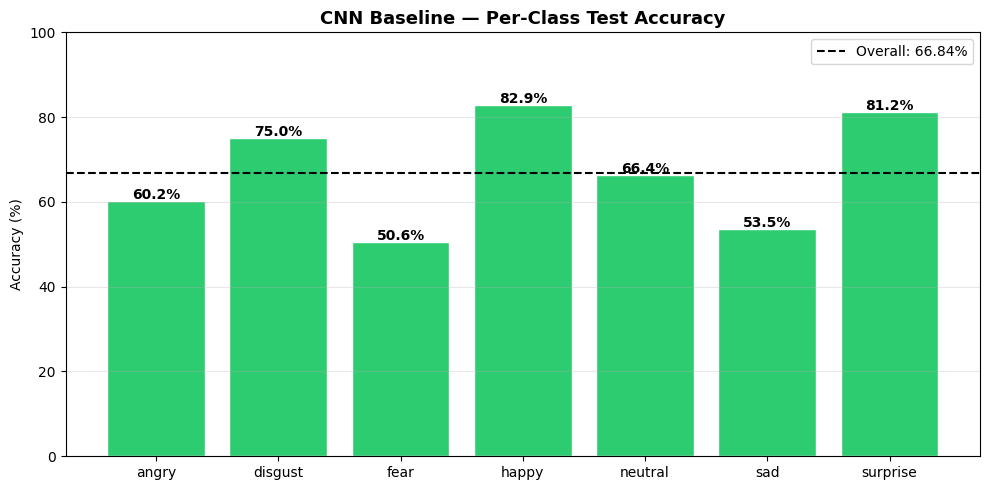


✅ All CNN outputs saved.


In [1]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  FER-2013 — CNN Baseline                                        ║
# ║  Test set evaluated ONCE at end — never during training         ║
# ║  Course : Machine Learning, IGP-TUBS, Dr.-Ing. Maboudi          ║
# ╚══════════════════════════════════════════════════════════════════╝

# ═══════════════════════════════════════════════════════════
# CELL 1: Kaggle credentials
# ═══════════════════════════════════════════════════════════
import os, json, subprocess, sys
from pathlib import Path

subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "kaggle"])
kdir = os.path.expanduser("~/.kaggle")
os.makedirs(kdir, exist_ok=True)
with open(f"{kdir}/kaggle.json", "w") as f:
    json.dump({"username": "patilatharv",
               "key": "KGAT_6e476fff7b1550b8bc35669407cea260"}, f)
os.chmod(f"{kdir}/kaggle.json", 0o600)
print("✅ Kaggle credentials set")

# ═══════════════════════════════════════════════════════════
# CELL 2: Download FER-2013
# ═══════════════════════════════════════════════════════════
DATA_ROOT = Path("/content/fer2013")
subprocess.run(["kaggle", "datasets", "download",
                "-d", "msambare/fer2013",
                "--unzip", "-p", str(DATA_ROOT)], check=True)

train_dir = DATA_ROOT / "train"
test_dir  = DATA_ROOT / "test"
classes   = sorted([d.name for d in train_dir.iterdir() if d.is_dir()])
print(f"\n✅ Dataset ready | Classes: {classes}")
for cls in classes:
    print(f"  {cls:12s}: train={len(list((train_dir/cls).glob('*.jpg'))):5,}"
          f"  test={len(list((test_dir/cls).glob('*.jpg'))):4,}")

# ═══════════════════════════════════════════════════════════
# CELL 3: Imports
# ═══════════════════════════════════════════════════════════
import torch, torch.nn as nn, copy, time
import json as _json
from torch.utils.data import DataLoader, random_split
from torch.optim import AdamW
from torch.optim.lr_scheduler import SequentialLR, LinearLR, CosineAnnealingLR
import torchvision.transforms as T
import torchvision.datasets as datasets
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}")

# ═══════════════════════════════════════════════════════════
# CELL 4: DataLoaders
# ═══════════════════════════════════════════════════════════
EMOTIONS   = ['angry','disgust','fear','happy','neutral','sad','surprise']
SEED       = 42
BATCH_SIZE = 64

transform_train = T.Compose([
    T.Grayscale(), T.RandomHorizontalFlip(), T.RandomRotation(10),
    T.ColorJitter(brightness=0.2, contrast=0.2),
    T.ToTensor(), T.Normalize((0.5,), (0.5,))
])
transform_test = T.Compose([
    T.Grayscale(), T.ToTensor(), T.Normalize((0.5,), (0.5,))
])

train_ds  = datasets.ImageFolder(str(train_dir), transform=transform_train)
test_full = datasets.ImageFolder(str(test_dir),  transform=transform_test)
n_val     = len(test_full) // 2
n_test    = len(test_full) - n_val
torch.manual_seed(SEED)
val_ds, test_ds = random_split(test_full, [n_val, n_test])

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE,
                          shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=256,
                          shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=256,
                          shuffle=False, num_workers=2, pin_memory=True)

print(f"  Train : {len(train_ds):,}")
print(f"  Val   : {len(val_ds):,}  (50% test folder — model selection only)")
print(f"  Test  : {len(test_ds):,}  (50% test folder — held out, ONE evaluation at end)")

counts  = torch.zeros(7)
for _, lbl in train_ds: counts[lbl] += 1
weights = counts.sum() / (7 * counts)

# ═══════════════════════════════════════════════════════════
# CELL 5: CNN Architecture
# ═══════════════════════════════════════════════════════════
class CNN(nn.Module):
    def __init__(self, channels=[32,64,128,256], fc_hidden=512,
                 dropout_conv=0.25, dropout_fc=0.50, num_classes=7):
        super().__init__()
        blocks, in_ch = [], 1
        for out_ch in channels:
            blocks += [
                nn.Conv2d(in_ch, out_ch, 3, padding=1),
                nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
                nn.Conv2d(out_ch, out_ch, 3, padding=1),
                nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
                nn.MaxPool2d(2), nn.Dropout2d(dropout_conv)
            ]
            in_ch = out_ch
        self.features   = nn.Sequential(*blocks)
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(channels[-1]*3*3, fc_hidden),
            nn.BatchNorm1d(fc_hidden), nn.ReLU(inplace=True),
            nn.Dropout(dropout_fc),
            nn.Linear(fc_hidden, num_classes)
        )

    def forward(self, x):
        return self.classifier(self.features(x))

torch.manual_seed(SEED)
model    = CNN().to(DEVICE)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nCNN baseline | Parameters: {n_params:,}")

# ═══════════════════════════════════════════════════════════
# CELL 6: Hyperparameters
# ═══════════════════════════════════════════════════════════
LR, WD, MAX_EP, WARMUP_EP, PATIENCE = 3e-4, 1e-4, 120, 10, 10

criterion = nn.CrossEntropyLoss(weight=weights.to(DEVICE), label_smoothing=0.1)
optimizer = AdamW(model.parameters(), lr=LR, weight_decay=WD)
warmup    = LinearLR(optimizer, start_factor=0.2, end_factor=1.0, total_iters=WARMUP_EP)
cosine    = CosineAnnealingLR(optimizer, T_max=MAX_EP - WARMUP_EP, eta_min=1e-6)
scheduler = SequentialLR(optimizer, [warmup, cosine], milestones=[WARMUP_EP])

# ═══════════════════════════════════════════════════════════
# CELL 7: Training loop — VAL ONLY, test never touched
# ═══════════════════════════════════════════════════════════
def evaluate(model, loader):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            logits      = model(imgs)
            total_loss += criterion(logits, labels).item() * imgs.size(0)
            correct    += (logits.argmax(1) == labels).sum().item()
            total      += labels.size(0)
    return total_loss / total, correct / total

history = {
    'train_loss': [], 'val_loss': [],
    'train_acc':  [], 'val_acc':  [],
    'lr': []
}
best_val_acc, best_weights, patience_ctr, best_epoch = 0.0, None, 0, 0

print(f"\n{'Ep':>4}  {'LR':>10}  {'Tr Loss':>8}  {'Tr Acc':>7}  "
      f"{'Va Loss':>8}  {'Va Acc':>7}")
print("─" * 60)

t0 = time.time()

for epoch in range(1, MAX_EP + 1):
    # Train
    model.train()
    tr_loss, tr_correct, tr_total = 0.0, 0, 0
    for imgs, labels in train_loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        logits = model(imgs)
        loss   = criterion(logits, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        tr_loss    += loss.item() * imgs.size(0)
        tr_correct += (logits.argmax(1) == labels).sum().item()
        tr_total   += labels.size(0)

    scheduler.step()
    tr_loss /= tr_total
    tr_acc   = tr_correct / tr_total

    va_loss, va_acc = evaluate(model, val_loader)
    cur_lr = scheduler.get_last_lr()[0]

    history['train_loss'].append(tr_loss)
    history['val_loss'].append(va_loss)
    history['train_acc'].append(tr_acc)
    history['val_acc'].append(va_acc)
    history['lr'].append(cur_lr)

    star = ""
    if va_acc > best_val_acc:
        best_val_acc = va_acc
        best_weights = copy.deepcopy(model.state_dict())
        patience_ctr = 0; best_epoch = epoch; star = " ★"
    else:
        patience_ctr += 1

    print(f"{epoch:4d}  {cur_lr:10.2e}  {tr_loss:8.4f}  {tr_acc*100:6.2f}%  "
          f"{va_loss:8.4f}  {va_acc*100:6.2f}%{star}")

    if patience_ctr >= PATIENCE:
        print(f"\n⏹  Early stop @ ep {epoch}  "
              f"(best val {best_val_acc*100:.2f}% @ ep {best_epoch})")
        break

print(f"\n✅ Training done in {(time.time()-t0)/60:.1f} min")

# ═══════════════════════════════════════════════════════════
# CELL 8: Load best checkpoint → evaluate test set ONCE
# ═══════════════════════════════════════════════════════════
model.load_state_dict(best_weights)
torch.save(best_weights, "/content/cnn_seed42_best.pt")

model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for imgs, labels in test_loader:
        all_preds.append(model(imgs.to(DEVICE)).argmax(1).cpu())
        all_labels.append(labels)

preds          = torch.cat(all_preds).numpy()
labels_np      = torch.cat(all_labels).numpy()
test_acc_final = (preds == labels_np).mean()

print(f"\n{'='*50}")
print(f"  FINAL TEST RESULT  (best val checkpoint ep {best_epoch})")
print(f"  Test Accuracy : {test_acc_final*100:.2f}%")
print(f"  Best Val Acc  : {best_val_acc*100:.2f}%")
print(f"{'='*50}")

per_class_acc = []
for i, name in enumerate(EMOTIONS):
    mask = labels_np == i
    acc  = (preds[mask] == i).mean() if mask.sum() > 0 else 0.0
    per_class_acc.append(acc)
    print(f"  {name:12s}: {mask.sum():5d}  {acc*100:5.1f}%  "
          f"{'⚠️' if acc < 0.40 else '✅'}")

with open("/content/cnn_results.json", "w") as f:
    _json.dump({
        "model": "CNN_baseline", "seed": SEED,
        "test_acc": float(test_acc_final),
        "best_val_acc": float(best_val_acc),
        "best_epoch": best_epoch,
        "per_class_acc": {EMOTIONS[i]: float(per_class_acc[i]) for i in range(7)},
        "history": history
    }, f, indent=2)
print("💾 Saved → cnn_results.json  |  cnn_seed42_best.pt")

# ═══════════════════════════════════════════════════════════
# CELL 9: Visualizations
# ═══════════════════════════════════════════════════════════
ep_axis = range(1, len(history['train_loss']) + 1)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(f'CNN Baseline — Training Curves (FER-2013) | Test: {test_acc_final*100:.2f}%',
             fontsize=13, fontweight='bold')

axes[0].plot(ep_axis, history['train_loss'], color='#e74c3c', label='Train', lw=1.5)
axes[0].plot(ep_axis, history['val_loss'],   color='#3498db', label='Val',   lw=1.5)
axes[0].axvline(best_epoch, color='gray', ls=':', alpha=0.8, label=f'Best ep={best_epoch}')
axes[0].set_title('Loss'); axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('CE Loss'); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(ep_axis, [a*100 for a in history['train_acc']], color='#e74c3c', label='Train', lw=1.5)
axes[1].plot(ep_axis, [a*100 for a in history['val_acc']],   color='#3498db', label='Val',   lw=1.5)
axes[1].axvline(best_epoch, color='gray', ls=':', alpha=0.8)
axes[1].axhline(test_acc_final*100, color='black', ls='--', lw=1.5,
                label=f'Test={test_acc_final*100:.2f}% (final)')
axes[1].set_title('Accuracy'); axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)'); axes[1].legend(); axes[1].grid(alpha=0.3)

axes[2].plot(ep_axis, history['lr'], color='#9b59b6', lw=1.5)
axes[2].set_title('LR Schedule'); axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('LR'); axes[2].set_yscale('log'); axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('/content/cnn_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

fig, ax = plt.subplots(figsize=(8, 7))
cm = confusion_matrix(labels_np, preds, normalize='true')
sns.heatmap(cm, annot=True, fmt='.2f', cmap='Reds',
            xticklabels=EMOTIONS, yticklabels=EMOTIONS,
            ax=ax, vmin=0, vmax=1, annot_kws={'size': 10})
ax.set_title(f'CNN Baseline — Confusion Matrix\nTest: {test_acc_final*100:.2f}%',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Predicted'); ax.set_ylabel('True')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig('/content/cnn_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#2ecc71' if a >= 0.40 else '#e74c3c' for a in per_class_acc]
bars   = ax.bar(EMOTIONS, [a*100 for a in per_class_acc],
                color=colors, edgecolor='white')
for bar, acc in zip(bars, per_class_acc):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
            f'{acc*100:.1f}%', ha='center', fontsize=10, fontweight='bold')
ax.axhline(test_acc_final*100, color='black', ls='--', lw=1.5,
           label=f'Overall: {test_acc_final*100:.2f}%')
ax.set_ylabel('Accuracy (%)'); ax.set_ylim(0, 100)
ax.set_title('CNN Baseline — Per-Class Test Accuracy', fontsize=13, fontweight='bold')
ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('/content/cnn_perclass_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ All CNN outputs saved.")